<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bar Charts**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be provided to you in the form of an RDBMS.

You will use SQL queries to extract the necessary data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data

-   Visualize the relationship between two features

-   Visualize the composition of data

-   Visualize comparison of data


## Setup: Working with the Database
**Install the needed libraries**


In [1]:
!pip install pandas
!pip install numpy

In [2]:
!pip install matplotlib
!pip install seaborn

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


--2026-01-23 09:46:30--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  63.8MB/s    in 2.4s    

2026-01-23 09:46:32 (63.8 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Distributions


##### 1. Histogram of `ConvertedCompYearly`


Visualize the distribution of yearly compensation (`ConvertedCompYearly`) using a histogram.



In [4]:
q1=df['ConvertedCompYearly'].quantile(0.25)
q3=df['ConvertedCompYearly'].quantile(0.75)
iqr=q3-q1
up=q3+3*iqr
out=df[df['ConvertedCompYearly'] > up].index
df=df.drop(out)

<Axes: xlabel='ConvertedCompYearly', ylabel='Count'>

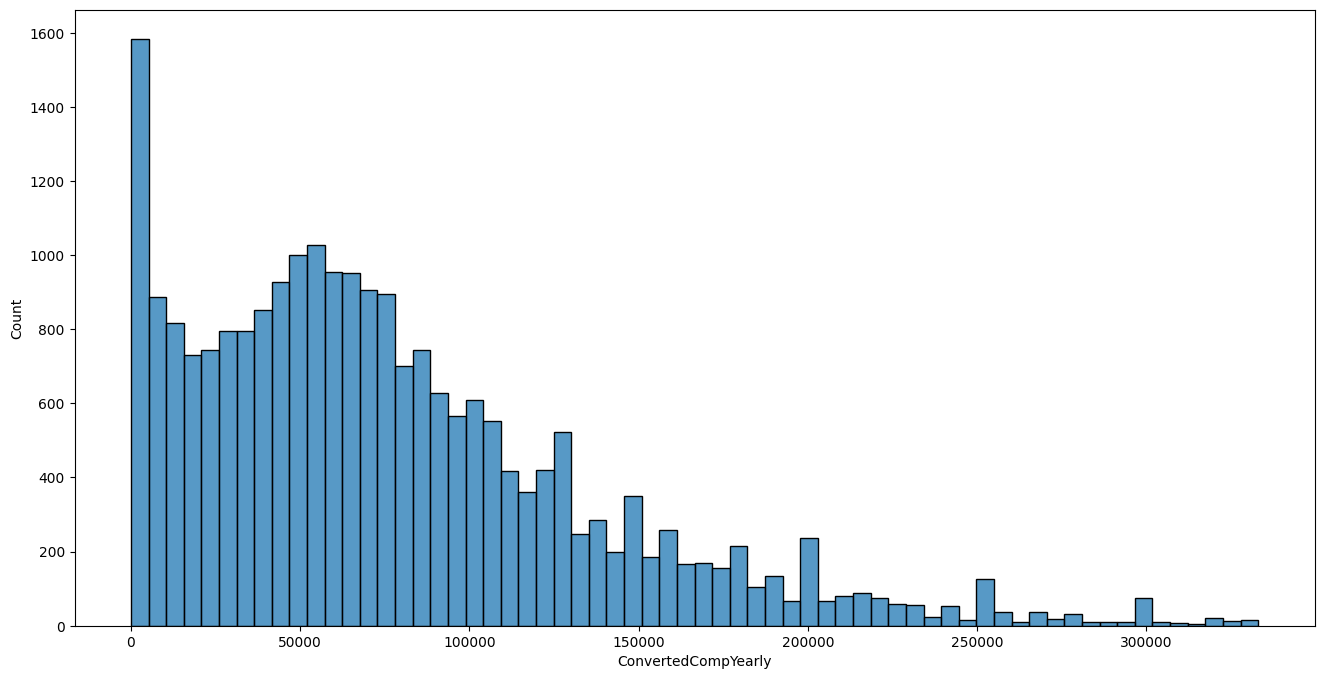

In [5]:
## Write your code here
plt.figure(figsize=(16,8))
sns.histplot(df['ConvertedCompYearly'])

##### 2. Box Plot of `Age`


Since `Age` is categorical in the dataset, convert it to numerical values for a box plot.



In [6]:
## Write your code here
age_map = {'35-44 years old': (44+35)/2,
           'Under 18 years old' : 16,
           '18-24 years old' : (24+18)/2,
           '25-34 years old' : (34+25)/2,
           '45-54 years old' : (54+45)/2,
           '55-64 years old' : (64+55)/2,
           '65 years or older' : (65+80)/2}
df['Age_norm'] = df['Age'].map(age_map)

<Axes: ylabel='Age_norm'>

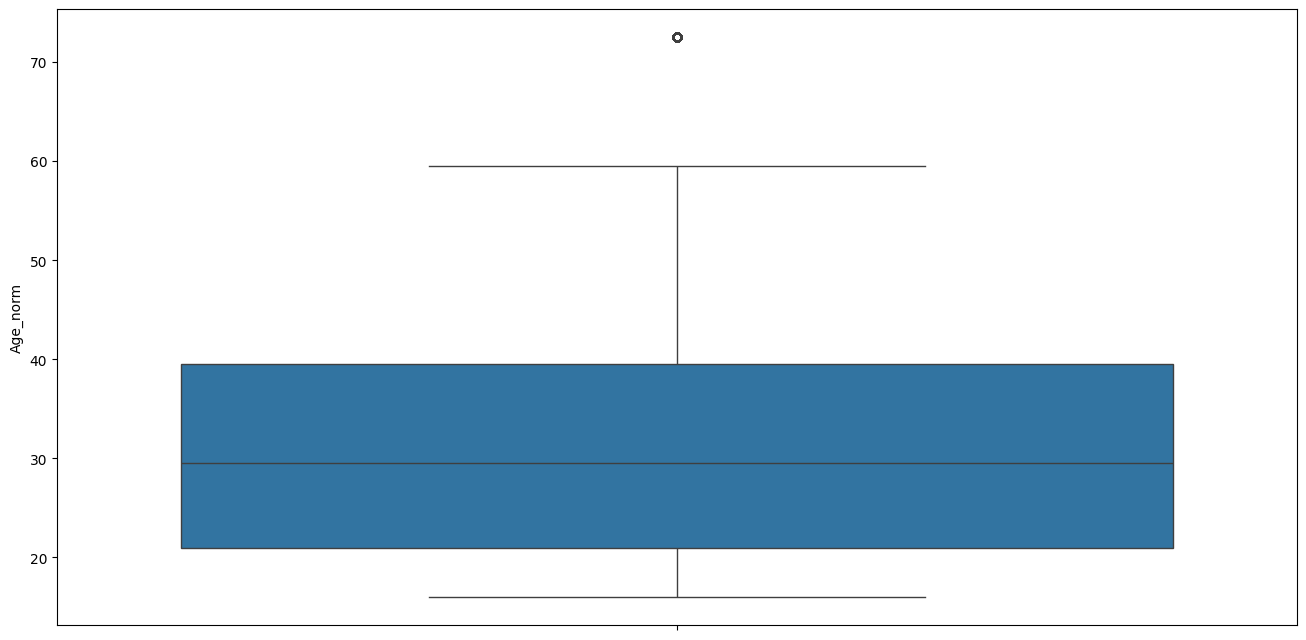

In [7]:
plt.figure(figsize=(16,8))
sns.boxplot(df['Age_norm'])

### Task 2: Visualizing Relationships in Data


##### 1. Scatter Plot of `Age_numeric` and `ConvertedCompYearly`


Explore the relationship between age and compensation.



Text(0.5, 1.0, 'Relationship between Age and Compensation')

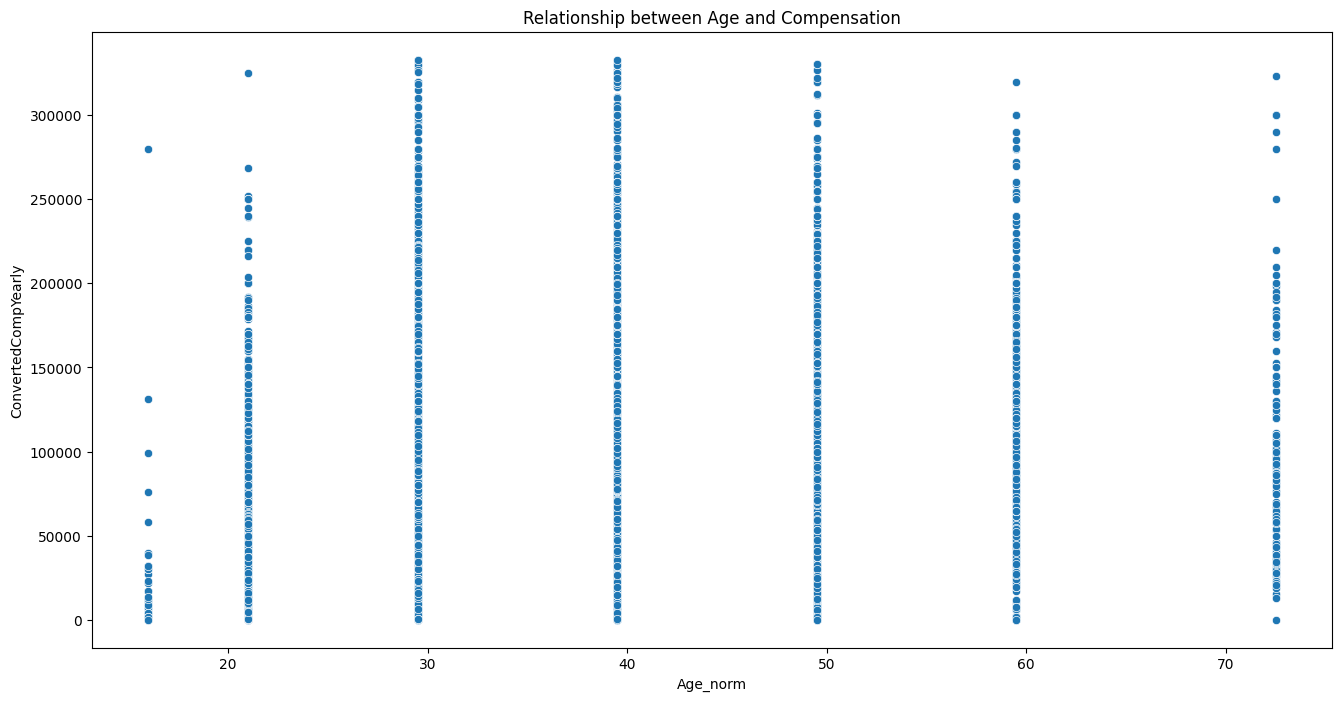

In [8]:
## Write your code here
plt.figure(figsize=(16,8))
sns.scatterplot(df, y='ConvertedCompYearly', x='Age_norm')
plt.title('Relationship between Age and Compensation')

##### 2. Bubble Plot of `ConvertedCompYearly` and `JobSatPoints_6` with `Age_numeric` as Bubble Size


Explore how compensation and job satisfaction are related, with age as the bubble size.


In [9]:
df['LogCompYearly']=np.log1p(df['ConvertedCompYearly'])

In [12]:
df1 = df[df['ConvertedCompYearly'] > 0] 
df1['comp_bin'] = pd.qcut(df1['ConvertedCompYearly'], q=20, duplicates='drop')
agg = (df1.groupby('comp_bin').agg(comp_median=('ConvertedCompYearly', 'median'),
                                  job_sat_mean=('JobSatPoints_6', 'mean'),
                                  count=('JobSatPoints_6', 'size')).reset_index())
agg['bubble_size'] = ((agg['count'] - agg['count'].min())/ (agg['count'].max() - agg['count'].min())) * 800 + 100
agg

,comp_bin,comp_median,job_sat_mean,count,bubble_size
0,"(0.999, 3395.7]",1093.5,31.184507,1156,524.068768
1,"(3395.7, 9344.8]",5986.0,31.579926,1156,524.068768
2,"(9344.8, 16985.4]",12946.0,31.383292,1156,524.068768
3,"(16985.4, 24878.2]",21175.5,27.452174,1156,524.068768
4,"(24878.2, 32222.0]",29132.0,26.383750,1172,560.744986
5,"(32222.0, 39891.8]",36518.0,27.899745,1140,487.392550
6,"(39891.8, 46370.0]",42962.0,24.440204,1159,530.945559
7,"(46370.0, 52975.8]",49407.0,23.829404,1153,517.191977
8,"(52975.8, 59073.0]",55472.0,23.500000,1291,833.524355
9,"(59073.0, 64444.0]",62296.0,26.410832,1102,400.286533


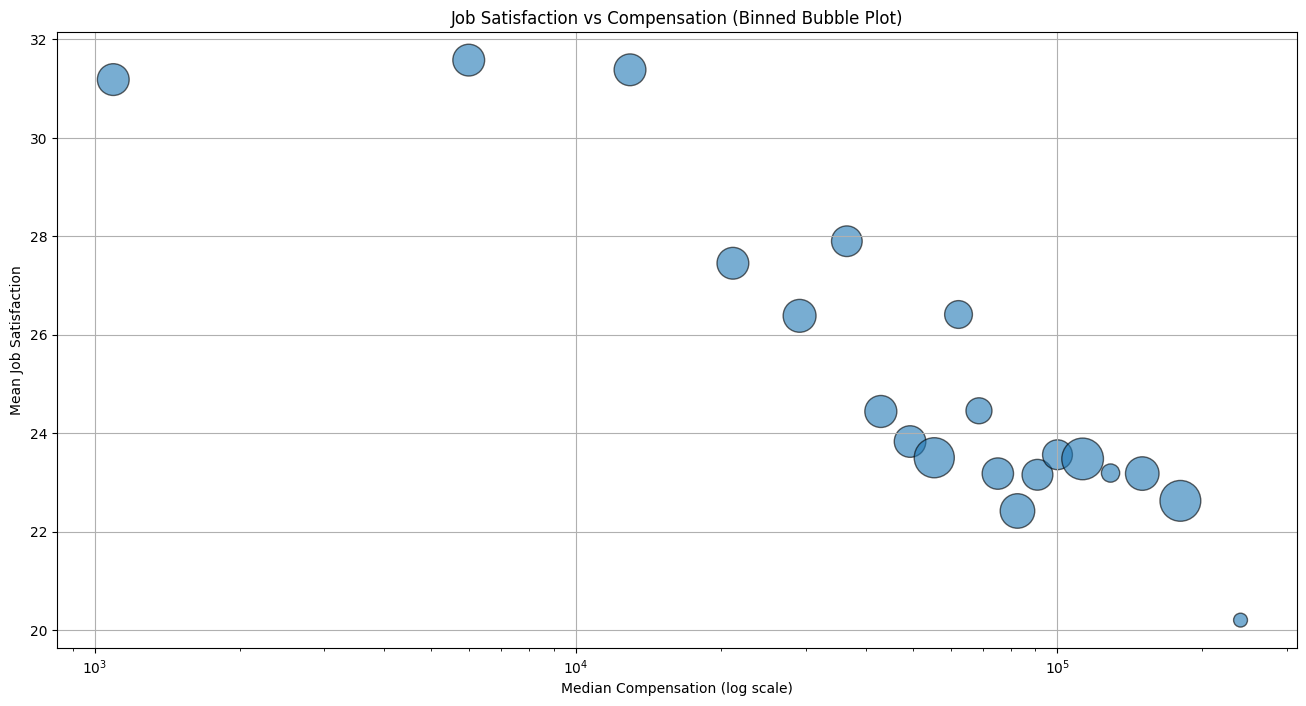

In [13]:
plt.figure(figsize=(16, 8))

plt.scatter(
    agg['comp_median'],
    agg['job_sat_mean'],
    s=agg['bubble_size'],
    alpha=0.6,
    edgecolor='black'
)

plt.xscale('log')
plt.xlabel('Median Compensation (log scale)')
plt.ylabel('Mean Job Satisfaction')
plt.title('Job Satisfaction vs Compensation (Binned Bubble Plot)')

plt.grid(True)
plt.show()

### Task 3: Visualizing Composition of Data with Bar Charts


##### 1. Horizontal Bar Chart of `MainBranch` Distribution


Visualize the distribution of respondents’ primary roles to understand their professional focus.



<Axes: ylabel='MainBranch'>

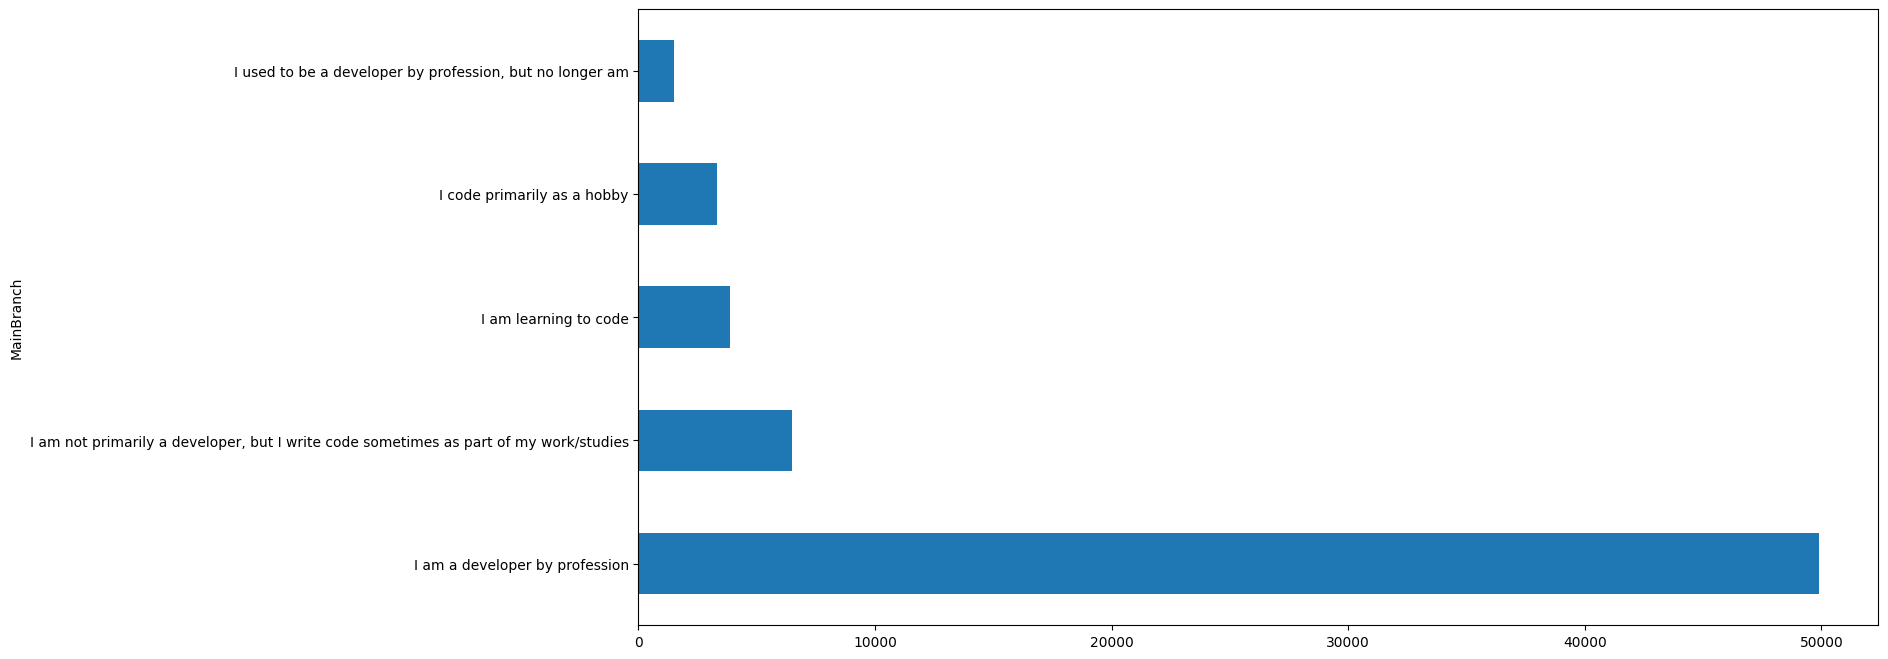

In [21]:
## Write your code here
plt.figure(figsize=(16,8))
df['MainBranch'].value_counts().plot(kind='barh')

##### 2. Vertical Bar Chart of Top 5 Programming Languages Respondents Want to Work With


Identify the most desired programming languages based on `LanguageWantToWorkWith`.



Text(0.5, 1.0, 'Top 5 Programming Languages Respondents Want To Work With')

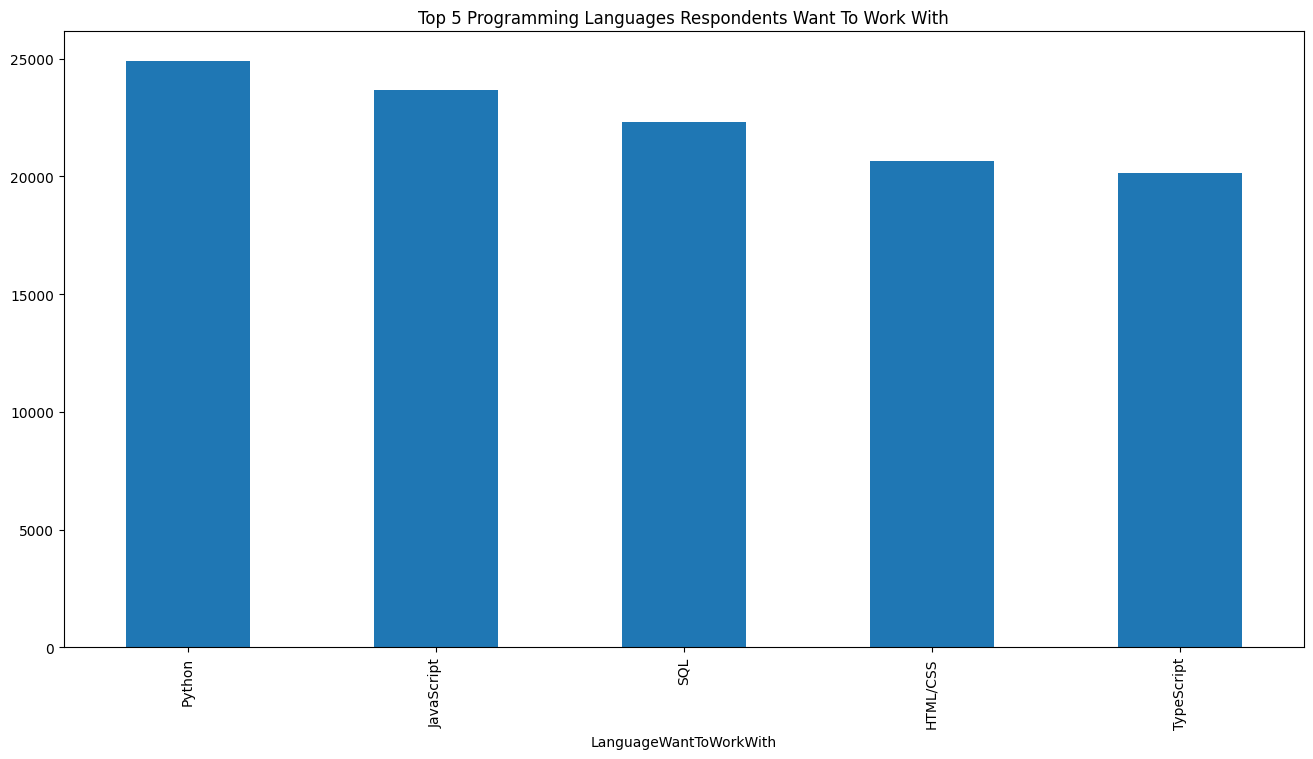

In [24]:
## Write your code here
df['LanguageWantToWorkWith'].str.split(';').explode().reset_index(drop=True).value_counts().head().plot(kind='bar', figsize=(16,8))
plt.title('Top 5 Programming Languages Respondents Want To Work With')

##### 3. Stacked Bar Chart of Median `JobSatPoints_6` and `JobSatPoints_7` by Age Group


Compare job satisfaction metrics across different age groups with a stacked bar chart.


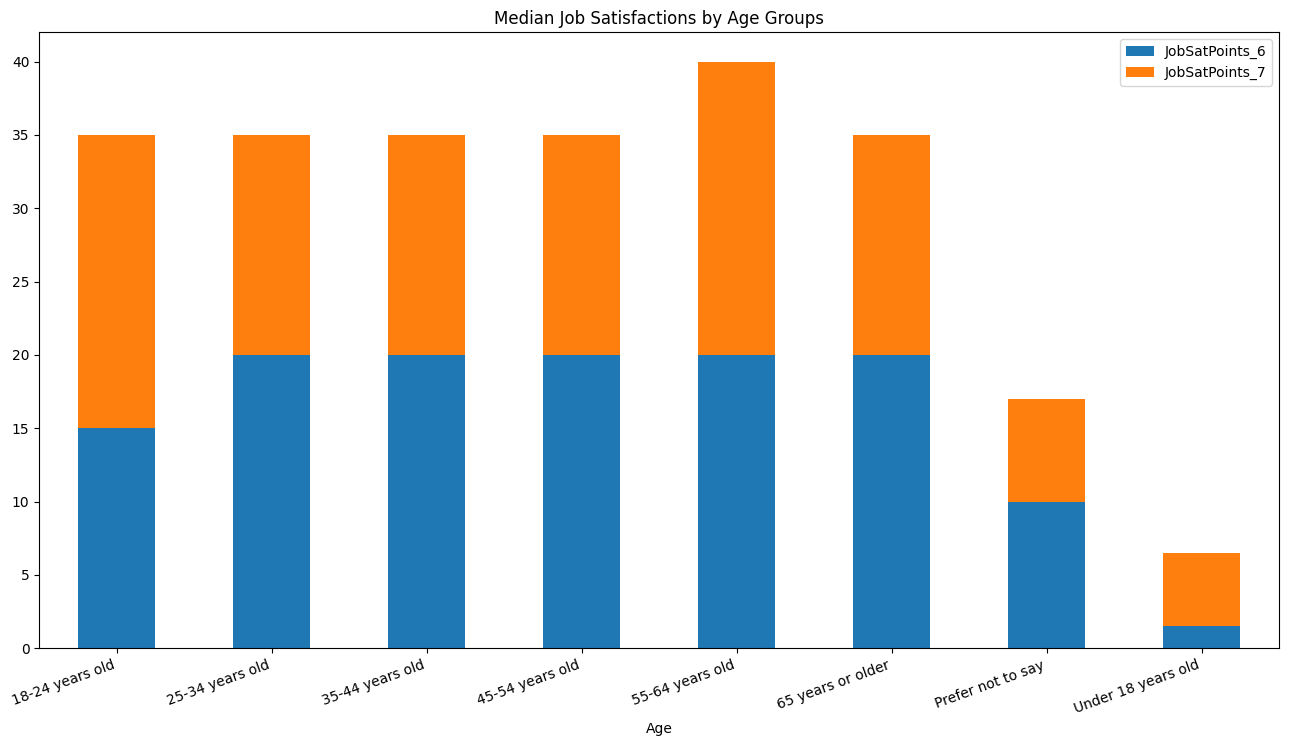

In [32]:
## Write your code here
df.groupby(['Age'])[['JobSatPoints_6', 'JobSatPoints_7']].median().plot(kind='bar', stacked=True, figsize=(16,8))
plt.title('Median Job Satisfactions by Age Groups')
plt.xticks(rotation=20, ha='right');

##### 4. Bar Chart of Database Popularity (`DatabaseHaveWorkedWith`)


Identify the most commonly used databases among respondents by visualizing `DatabaseHaveWorkedWith`.



Text(0.5, 1.0, 'Top 10 Commonly Used Databases')

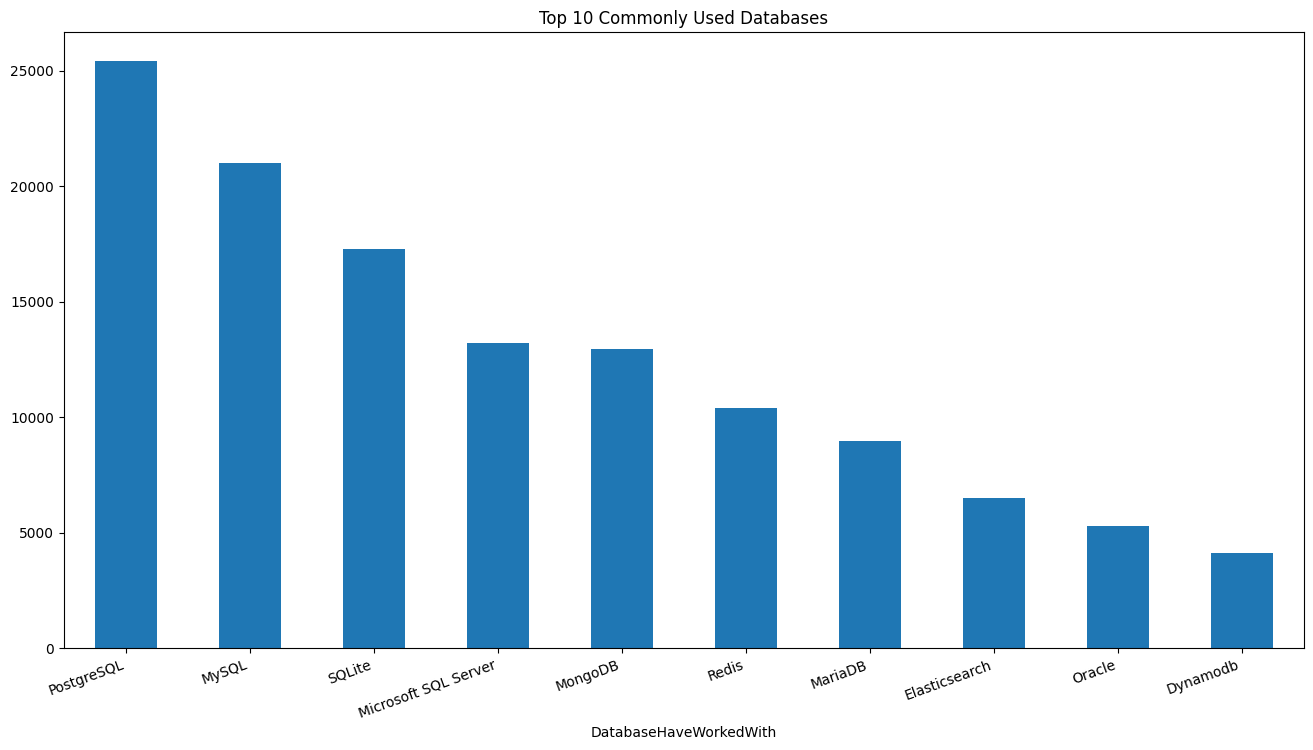

In [35]:
## Write your code here
df['DatabaseHaveWorkedWith'].str.split(';')\
.explode().reset_index(drop=True)\
.value_counts().head(10).plot(kind='bar', figsize=(16,8))
plt.xticks(rotation=20,ha='right');
plt.title('Top 10 Commonly Used Databases')

### Task 4: Visualizing Comparison of Data with Bar Charts


##### 1. Grouped Bar Chart of Median `ConvertedCompYearly` for Different Age Groups


Compare median compensation across multiple age groups with a grouped bar chart.



Text(0.5, 1.0, 'Median Yearly Compensation for Different Age Groups')

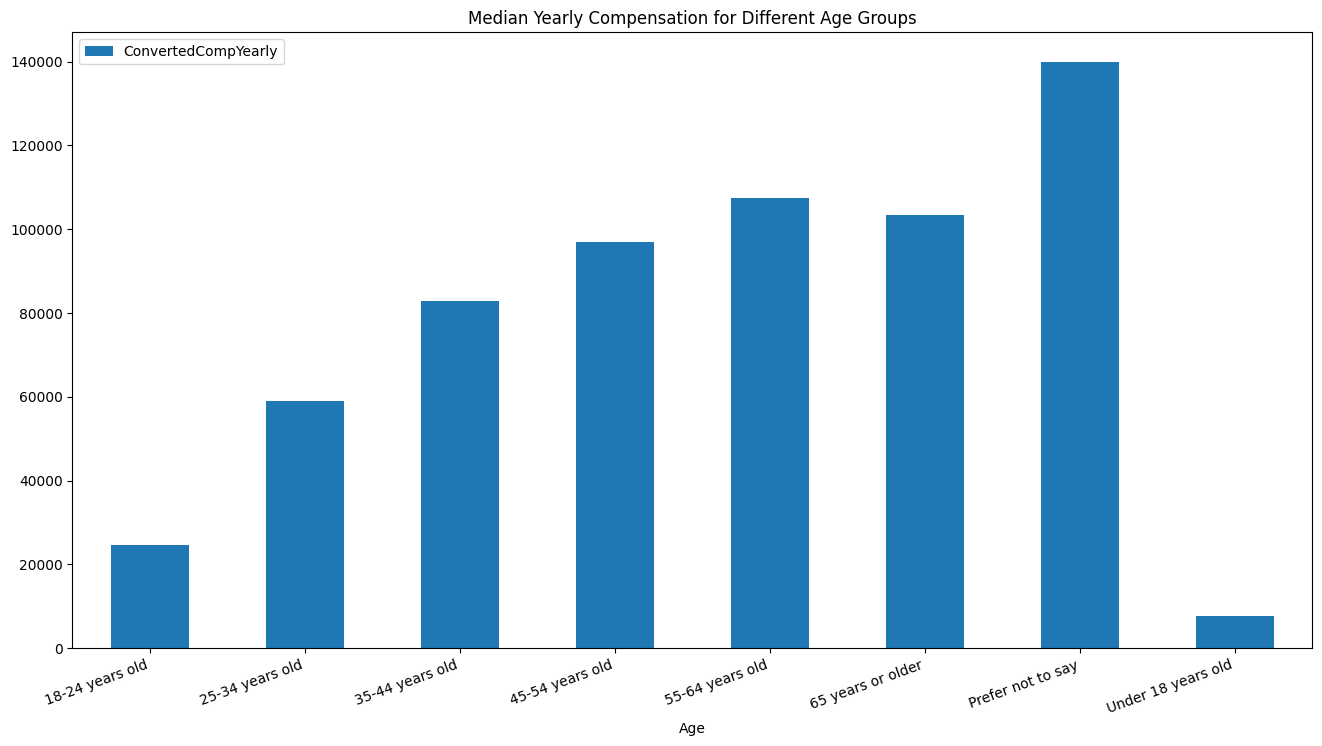

In [37]:
## Write your code here
df.groupby(['Age'])[['ConvertedCompYearly']].median().plot(kind='bar', figsize=(16,8))
plt.xticks(rotation=20, ha='right');
plt.title('Median Yearly Compensation for Different Age Groups')

##### 2. Bar Chart of Respondent Count by Country


Show the distribution of respondents by country to see which regions are most represented.



In [45]:
countries = [
    "Afghanistan", "Albania", "Algeria", "Andorra", "Angola",
    "Antigua and Barbuda", "Argentina", "Armenia", "Australia", "Austria", "Azerbaijan",
    "Bahamas", "Bahrain", "Bangladesh", "Barbados", "Belarus", "Belgium", "Belize",
    "Benin", "Bhutan", "Bolivia", "Bosnia and Herzegovina", "Botswana", "Brazil",
    "Brunei", "Bulgaria", "Burkina Faso", "Burundi",
    "Cabo Verde", "Cambodia", "Cameroon", "Canada", "Central African Republic", "Chad",
    "Chile", "China", "Colombia", "Comoros", "Congo", "Costa Rica",
    "Côte d'Ivoire", "Croatia", "Cuba", "Cyprus", "Czech Republic",
    "Denmark", "Djibouti", "Dominica", "Dominican Republic",
    "Ecuador", "Egypt", "El Salvador", "Equatorial Guinea", "Eritrea", "Estonia",
    "Eswatini", "Ethiopia",
    "Fiji", "Finland", "France",
    "Gabon", "Gambia", "Georgia", "Germany", "Ghana", "Greece", "Grenada",
    "Guatemala", "Guinea", "Guinea-Bissau", "Guyana",
    "Haiti", "Honduras", "Hungary",
    "Iceland", "India", "Indonesia", "Iran", "Iraq", "Ireland", "Israel", "Italy",
    "Jamaica", "Japan", "Jordan",
    "Kazakhstan", "Kenya", "Kiribati", "Kuwait", "Kyrgyzstan",
    "Laos", "Latvia", "Lebanon", "Lesotho", "Liberia", "Libya", "Liechtenstein",
    "Lithuania", "Luxembourg",
    "Madagascar", "Malawi", "Malaysia", "Maldives", "Mali", "Malta",
    "Marshall Islands", "Mauritania", "Mauritius", "Mexico", "Micronesia",
    "Moldova", "Monaco", "Mongolia", "Montenegro", "Morocco", "Mozambique", "Myanmar",
    "Namibia", "Nauru", "Nepal", "Netherlands", "New Zealand", "Nicaragua",
    "Niger", "Nigeria", "North Korea", "North Macedonia", "Norway",
    "Oman",
    "Pakistan", "Palau", "Panama", "Papua New Guinea", "Paraguay", "Peru",
    "Philippines", "Poland", "Portugal",
    "Qatar",
    "Romania", "Russian Federation", "Rwanda",
    "Saint Kitts and Nevis", "Saint Lucia", "Saint Vincent and the Grenadines",
    "Samoa", "San Marino", "Sao Tome and Principe", "Saudi Arabia", "Senegal",
    "Serbia", "Seychelles", "Sierra Leone", "Singapore", "Slovakia", "Slovenia",
    "Solomon Islands", "Somalia", "South Africa", "South Sudan", "Spain",
    "Sri Lanka", "Sudan", "Suriname", "Sweden", "Switzerland", "Syria",
    "Tajikistan", "Tanzania", "Thailand", "Timor-Leste", "Togo", "Tonga",
    "Trinidad and Tobago", "Tunisia", "Turkey", "Turkmenistan", "Tuvalu",
    "Uganda", "Ukraine", "United Arab Emirates", "United Kingdom of Great Britain and Northern Ireland", "United States of America",
    "Uruguay", "Uzbekistan",
    "Vanuatu", "Vatican City", "Venezuela", "Vietnam",
    "Yemen",
    "Zambia", "Zimbabwe",
    "Holy See", "Palestine", 'kosovo', 'taiwan', 
]

df['Country'] = (
    df['Country']
    .astype(str)
    .str.strip()
    .str.lower()
)

all_countries_clean = [c.strip().lower() for c in countries]

new_list = {'iran, islamic republic of...' : 'iran',
             'republic of north macedonia' : 'macedonia',
             'united republic of tanzania' : 'tanzania',
             'viet nam' : 'vietnam',
             'venezuela, bolivarian republic of...': 'venezuela',
             'republic of korea' : 'south korea',
             'republic of moldova' : 'moldova', 
             'hong kong (s.a.r.)' : 'china', 
             "lao people's democratic republic" : 'laos', 
             'democratic republic of the congo' : 'congo', 
             'syrian arab republic' : 'syria',
             'swaziland' : 'eswatini', 
             "democratic people's republic of korea" : 'north korea',
             'congo, republic of the...' : 'congo', 
             'libyan arab jamahiriya' : 'lybia',
             'cape verde' : 'cabo verde', 
             'brunei darussalam' : 'brunei',
             'micronesia, federated states of...' : 'micronesia',
             'macedonia' : 'north macedonia',
            'united kingdom of great britain and northern ireland' : 'UK',
            'united states of america' : 'USA',
            'dominican republic' : 'dominica'
           }
invalid_countries = df.loc[~df['Country'].isin(all_countries_clean), 'Country']
df['Country'] = df['Country'].replace(new_list)
df['Country']=df['Country'].str.capitalize()
df['Country'] = df['Country'].replace({'Usa': 'USA','Uk': 'UK'})

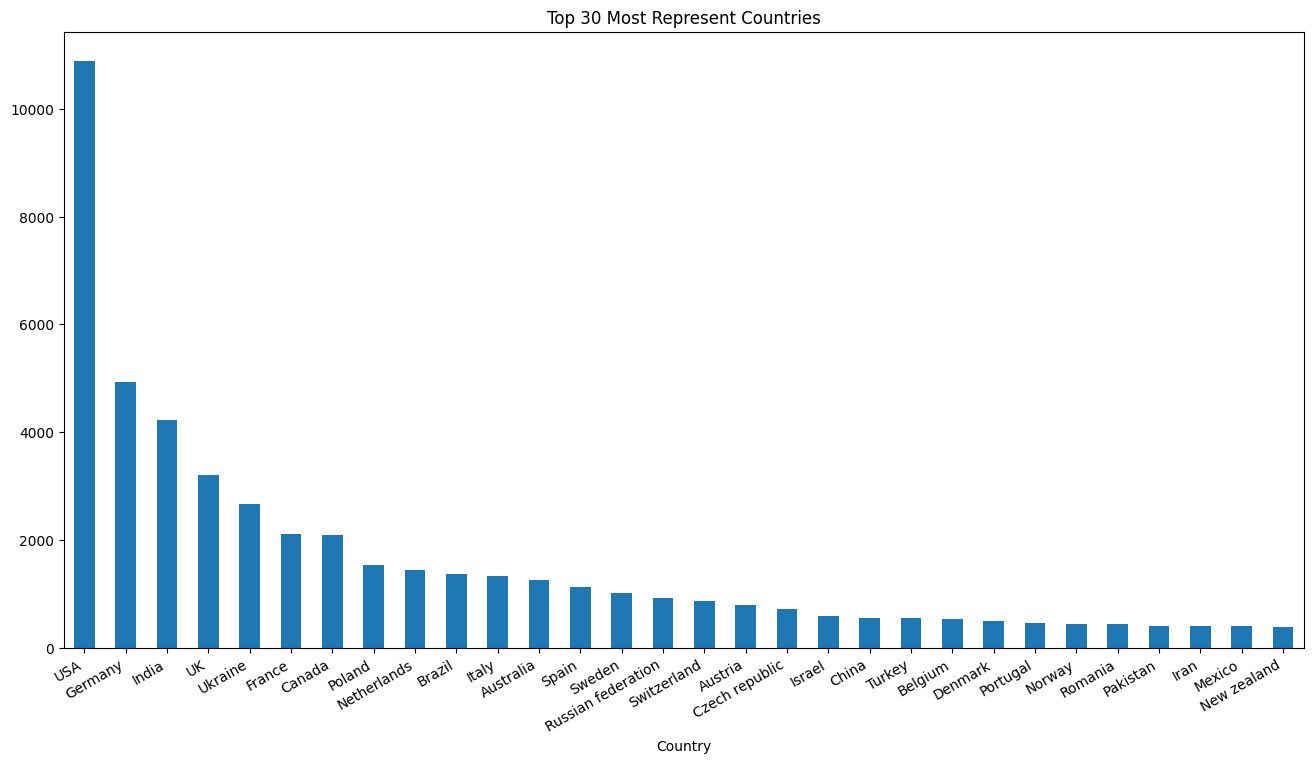

In [51]:
## Write your code here
df['Country'].value_counts().head(30).plot(kind='bar', figsize=(16,8))
plt.title('Top 30 Most Represent Countries');
plt.xticks(rotation=30, ha='right');

### Final Step: Review


This lab demonstrates how to create and interpret different types of bar charts, allowing you to analyze the composition, comparison, and distribution of categorical data in the Stack Overflow dataset, including main professional branches, programming language preferences, and compensation by age group. Bar charts effectively compare counts and median values across various categories.


## Summary


After completing this lab, you will be able to:
- Create a horizontal bar chart to visualize the distribution of respondents' primary roles, helping to understand their professional focus.
- Develop a vertical bar chart to identify the most desired programming languages based on the LanguageWantToWorkWith variable.
- Use a stacked bar chart to compare job satisfaction metrics across different age groups.
- Create a bar chart to visualize the most commonly used databases among respondents using the DatabaseHaveWorkedWith variable.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
